# Simon's Algorithm

Simon's Algorithm Analysis: Secret = '11'

1. Circuit Visualisation

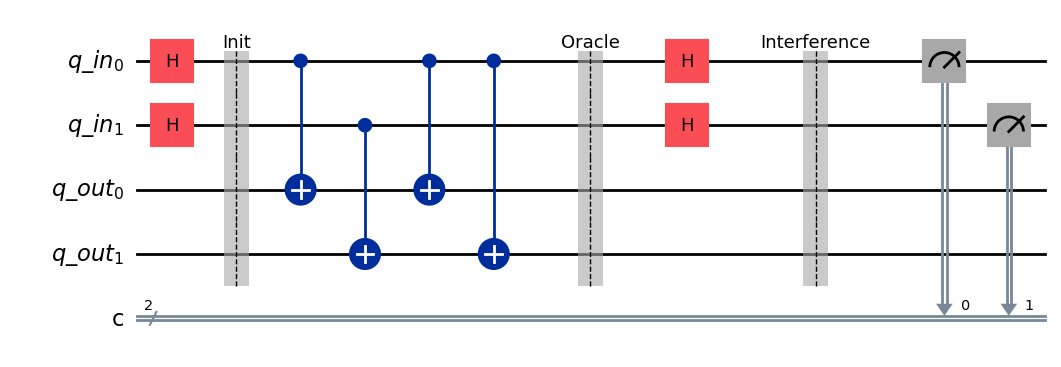

2. Unitary Evolution

The 16x16 unitary matrix describing the full circuit:


<IPython.core.display.Latex object>

3. Quantum State Representation

Exact Statevector prior to measurement:


<IPython.core.display.Latex object>


Final DensityMatrix prior to measurement:


<IPython.core.display.Latex object>

4. State Visualisation

State prior to measurement (Bloch Spheres):


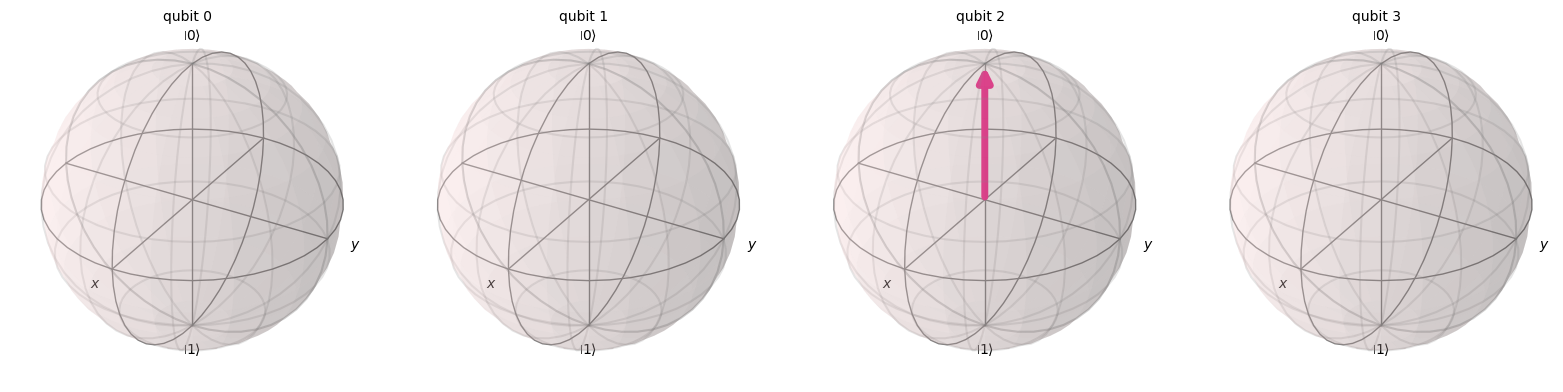


State prior to measurement (Q-Sphere):


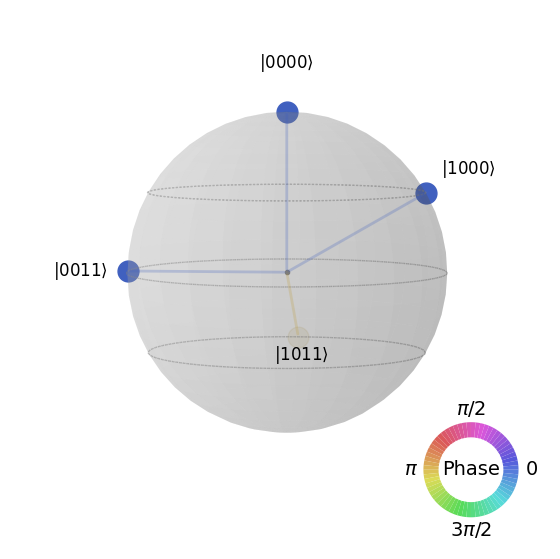

5. Measurement Analysis

Raw measurement counts: {'11': 537, '00': 487}


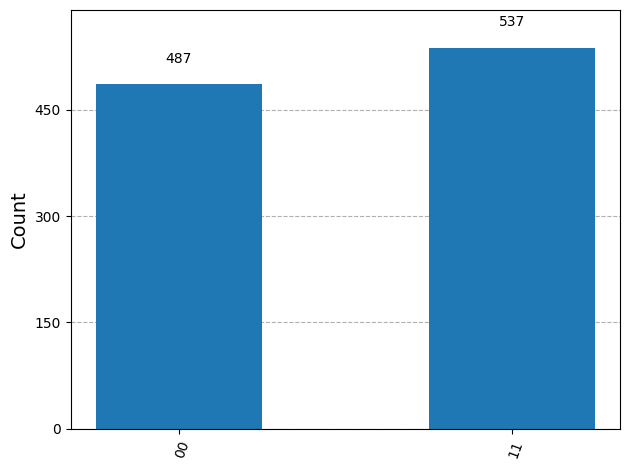

6. Verification

Secret string (s): 11
Verifying the dot product of measured strings (z) with secret string (s) modulo 2:
z = 11 -> s·z mod 2 = 0
z = 00 -> s·z mod 2 = 0

Success: All measured strings are orthogonal to the secret string '11'.


In [35]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere, array_to_latex
from IPython.display import display, Markdown

# ==========================================
# CONFIGURATION
# ==========================================
secret_string = "11"
n = len(secret_string)

# 1. Set up Registers & Circuit
# Simon's algorithm requires n input qubits and n ancilla (output) qubits
qr_in = QuantumRegister(n, name="q_in")
qr_out = QuantumRegister(n, name="q_out")
cr = ClassicalRegister(n, name="c")
qc = QuantumCircuit(qr_in, qr_out, cr)

# 2. Initialisation
for i in range(n):
    qc.h(qr_in[i])
qc.barrier(label="Init")

# 3. Oracle Construction
# First, copy inputs to outputs (f(x) = x initially)
for i in range(n):
    qc.cx(qr_in[i], qr_out[i])

# Create the collision for the secret string s
pivot = secret_string.find('1')
if pivot != -1:
    # Reverse string to match Qiskit's little-endian ordering
    reversed_s = secret_string[::-1] 
    for i in range(n):
        if reversed_s[i] == '1':
            qc.cx(qr_in[pivot], qr_out[i])
qc.barrier(label="Oracle")

# 4. Final Interference
for i in range(n):
    qc.h(qr_in[i])
qc.barrier(label="Interference")

# ==========================================
# EXTRACT EXACT MATH BEFORE MEASUREMENT
# ==========================================
unitary = Operator(qc)
final_state = Statevector(qc)
final_density = DensityMatrix(qc)

# 5. Measurement (measure only the input register)
for i in range(n):
    qc.measure(qr_in[i], cr[i])

# 6. Execute on AerSimulator
simulator = AerSimulator()
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
result = job.result()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown(f"Simon's Algorithm Analysis: Secret = '{secret_string}'"))

display(Markdown("1. Circuit Visualisation"))
display(qc.draw('mpl'))

display(Markdown("2. Unitary Evolution"))
# Guardrail: A total of 4 qubits (n=2) yields a 16x16 matrix. 
# Anything larger risks crashing the Jupyter output.
total_qubits = 2 * n
if total_qubits <= 4: 
    print(f"The {2**total_qubits}x{2**total_qubits} unitary matrix describing the full circuit:")
    display(array_to_latex(unitary.data, prefix="U_{circuit} = ", max_size=16))
else:
    print(f"Unitary matrix omitted: {total_qubits} total qubits results in a matrix too large for clean display.")

display(Markdown("3. Quantum State Representation"))
print("Exact Statevector prior to measurement:")
display(final_state.draw('latex'))

print("\nFinal DensityMatrix prior to measurement:")
display(final_density.draw('latex'))

display(Markdown("4. State Visualisation"))
print("State prior to measurement (Bloch Spheres):")
display(plot_bloch_multivector(final_state))

print("\nState prior to measurement (Q-Sphere):")
display(plot_state_qsphere(final_state))

display(Markdown("5. Measurement Analysis"))
counts = result.get_counts()
print(f"Raw measurement counts: {counts}")
display(plot_histogram(counts))

# 6. Final Verification Logic
display(Markdown("6. Verification"))
print(f"Secret string (s): {secret_string}")
print("Verifying the dot product of measured strings (z) with secret string (s) modulo 2:")

all_valid = True
for z in counts.keys():
    # Calculate s·z mod 2
    dot_product = sum(int(s_bit) * int(z_bit) for s_bit, z_bit in zip(secret_string, z)) % 2
    print(f"z = {z} -> s·z mod 2 = {dot_product}")
    if dot_product != 0:
        all_valid = False

if all_valid:
    print(f"\nSuccess: All measured strings are orthogonal to the secret string '{secret_string}'.")
    if set(counts.keys()) == {'00'}:
        print("Note: If only '00' was measured, the function is 1-to-1 (s='00').")
else:
    print("\nError: Found a measurement not orthogonal to the secret string.")